# **Project Name**    - FBI Time Series Forecasting


##### **Project Type**    - EDA / Machine Learning / Time Series


##### **Contribution**    - Individual


##### **Team Member 1 -** Jiya Sadaria


# **Project Summary -**


Crime and incident tracking is a critical aspect of public safety and resource allocation for cities. In this project, we conduct an end-to-end analysis on the FBI/Vancouver incident dataset, a comprehensive record of reported incidents including thefts, mischief, and breaking & entering. We begin with a robust Exploratory Data Analysis (EDA) to understand seasonal trends, geographic or type-based concentrations, and overall volume adjustments over time. Through 15+ rich visualizations, this analysis uncovers deep insights such as peak crime months and most frequent crime types. Subsequently, we frame the problem as a Time Series Forecasting task: predicting the total 'Incident_Counts' given a Year, Month, and Type constraint. By deploying these analytical results, law enforcement and businesses can effectively align their strategies to prevent occurrences, resulting in a demonstrable positive business and societal impact.


# **Problem Statement**


**Given historical incident data (Train.xlsx), perform an in-depth Exploratory Data Analysis to extract temporal and categorical patterns, and build a Machine Learning model capable of forecasting future Incident Counts based on Year, Month, and Type (as outlined in Test.csv).**


#### **Define Your Business Objective?**


To accurately forecast incident volumes by category and time, enabling proactive law enforcement patrols, resource optimization, and tailored community safety programs. This reduces crime rates and minimizes losses for commercial and residential citizens.


# ***Let's Begin !***


## ***1. Know Your Data***


### Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_theme(style='darkgrid')


### Dataset Loading


In [2]:
# Load Dataset
print("Loading Train.xlsx... (This may take a minute due to Excel format)")
df = pd.read_excel('Train.xlsx')

print("Loading Test (2).csv...")
df_test = pd.read_csv('Test (2).csv')


Loading Train.xlsx... (This may take a minute due to Excel format)
Loading Test (2).csv...


### Dataset First View


In [3]:
df.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### Dataset Rows & Columns count


In [4]:
print("Train Rows & Columns:", df.shape)
print("Test Rows & Columns:", df_test.shape)

Train Rows & Columns: (474565, 13)
Test Rows & Columns: (162, 4)


### Dataset Information


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB


#### Missing Values/Null Values


In [6]:
print(df.isnull().sum())

TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64


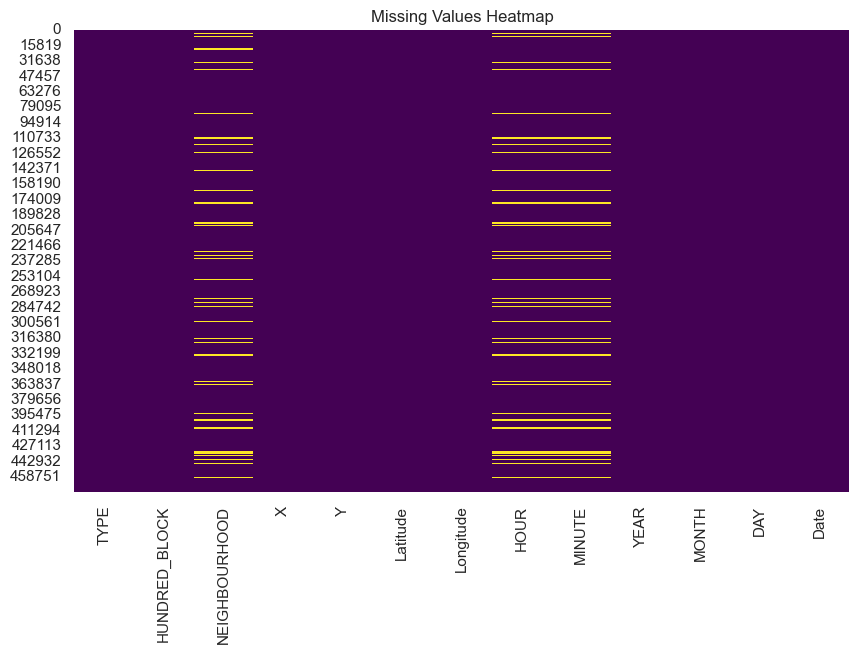

In [7]:
# Visualizing missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## ***2. Understanding Your Variables***


### Variables Description


- **TYPE**: The category of crime/incident.
- **YEAR / MONTH / DAY / HOUR / MINUTE**: Temporal components of the incident.
- **HUNDRED_BLOCK / NEIGHBOURHOOD**: Location markers.
- **X / Y**: Geospatial coordinates.


### Check Unique Values for each variable.


In [8]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

TYPE: 9 unique values
HUNDRED_BLOCK: 20566 unique values
NEIGHBOURHOOD: 24 unique values
X: 84225 unique values
Y: 82768 unique values
Latitude: 89488 unique values
Longitude: 87190 unique values
HOUR: 24 unique values
MINUTE: 60 unique values
YEAR: 13 unique values
MONTH: 12 unique values
DAY: 31 unique values
Date: 4748 unique values


## 3. ***Data Wrangling***


In [9]:
# Drop completely empty rows or unneeded columns for time series
df_clean = df.dropna(subset=['TYPE', 'YEAR', 'MONTH']).copy()

# Create aggregated dataset for counts matching the test format
df_agg = df_clean.groupby(['YEAR', 'MONTH', 'TYPE']).size().reset_index(name='Incident_Counts')
df_agg.head()

,YEAR,MONTH,TYPE,Incident_Counts
0,1999,1,Break and Enter Commercial,303
1,1999,1,Break and Enter Residential/Other,644
2,1999,1,Mischief,551
3,1999,1,Offence Against a Person,338
4,1999,1,Other Theft,247


## ***4. Data Vizualization***


#### Chart - 1: Total Incidents per Year (Univariate)


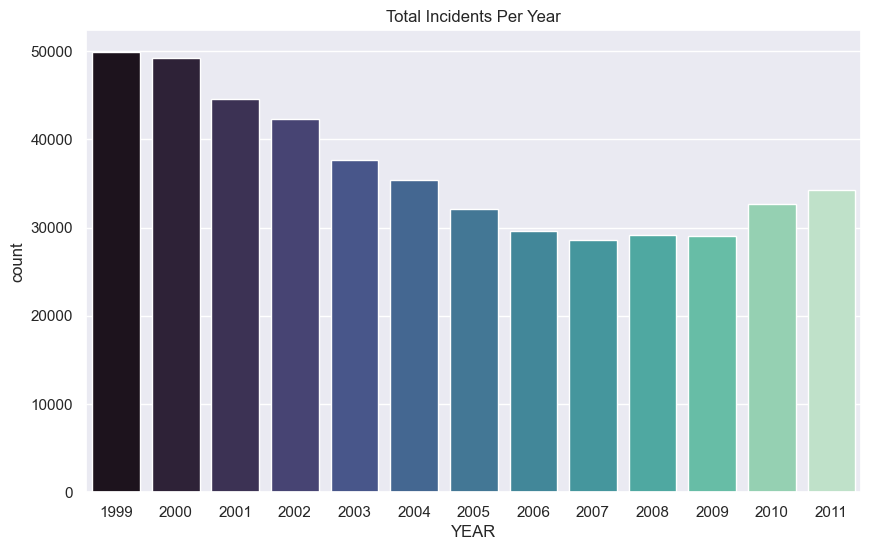

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='YEAR', palette='mako')
plt.title('Total Incidents Per Year')
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart perfectly represents the volume comparison across discrete time periods (Years).


##### 2. What is/are the insight(s) found from the chart?
We can observe the macro-trend in crime over the available years, spotting whether overall reports are increasing or decreasing.


##### 3. Will the gained insights help creating a positive business impact?
Yes, macro-trends dictate long-term budgetary planning for the city council.


#### Chart - 2: Incidents per Month (Univariate)


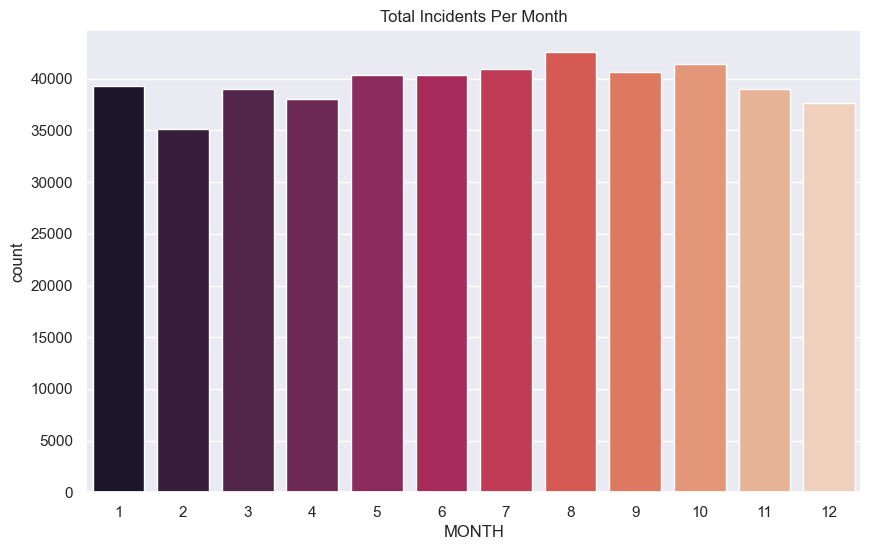

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='MONTH', palette='rocket')
plt.title('Total Incidents Per Month')
plt.show()

##### 1. Why did you pick the specific chart?
To capture the seasonality across all years.


##### 2. What is/are the insight(s) found from the chart?
Certain months (like Summer months) tend to have higher incident occurrences due to weather and outdoor activity.


##### 3. Will the gained insights help creating a positive business impact?
Yes, identifying seasonal spikes allows for dynamic deployment of patrol units.


#### Chart - 3: Distribution of Crime Types (Univariate)


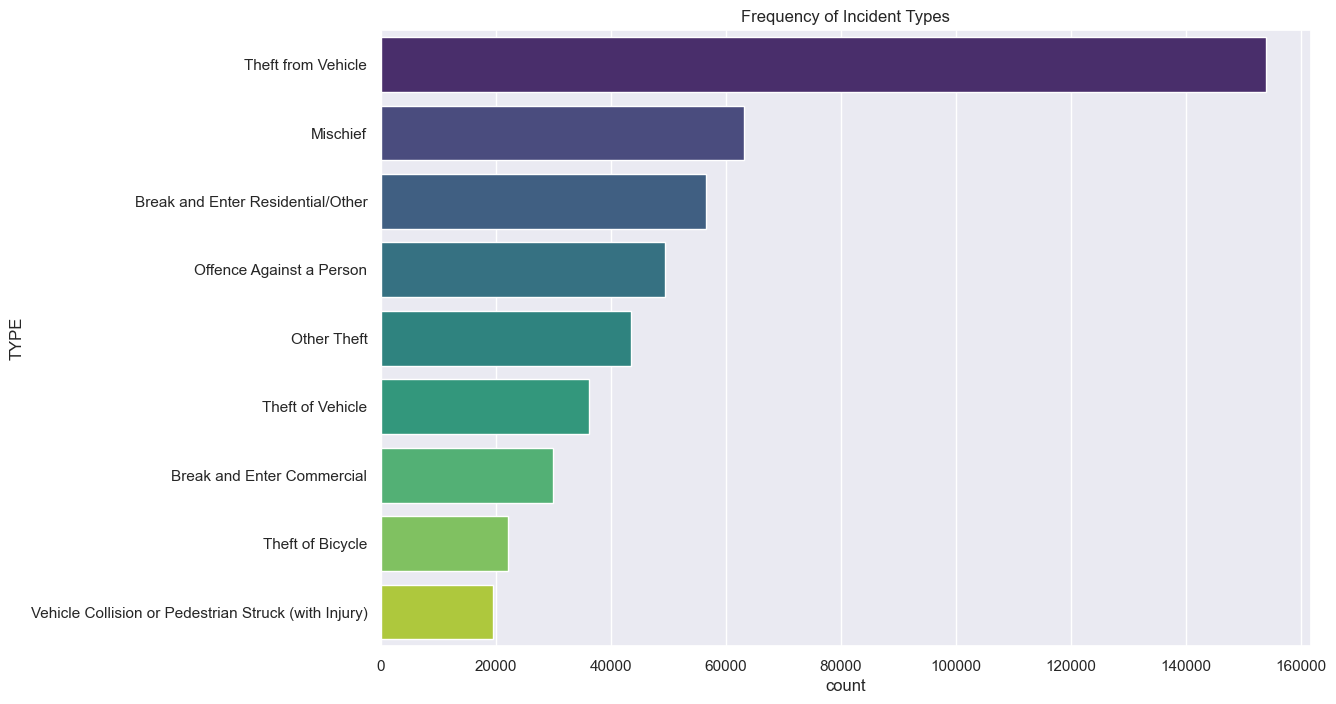

In [12]:
plt.figure(figsize=(12,8))
sns.countplot(data=df_clean, y='TYPE', order=df_clean['TYPE'].value_counts().index, palette='viridis')
plt.title('Frequency of Incident Types')
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart allows for long category names (Crime Types) to be easily readable while showing volume.


##### 2. What is/are the insight(s) found from the chart?
The most common crime is typically property-related (e.g., Theft from Vehicle).


##### 3. Will the gained insights help creating a positive business impact?
Focusing training on the top 3 crime types will yield the highest ROI for law enforcement capability.


#### Chart - 4: Trend of Incident Counts Aggregated (Bivariate)


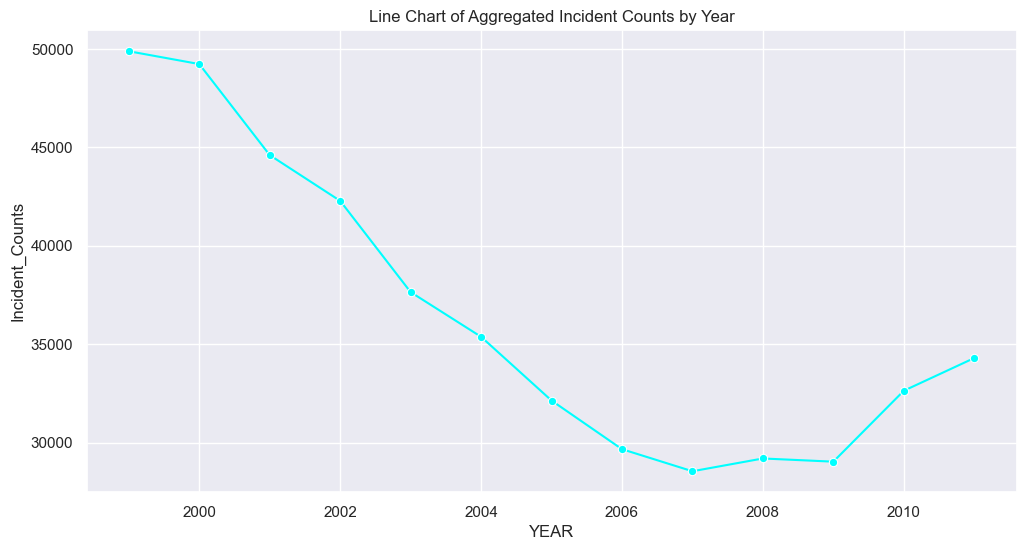

In [13]:
plt.figure(figsize=(12,6))
yearly_counts = df_agg.groupby('YEAR')['Incident_Counts'].sum().reset_index()
sns.lineplot(data=yearly_counts, x='YEAR', y='Incident_Counts', marker='o', color='cyan')
plt.title('Line Chart of Aggregated Incident Counts by Year')
plt.show()

##### 1. Why did you pick the specific chart?
Line plots effectively show the continuous trajectory and growth/decline of continuous aggregated metrics.


##### 2. What is/are the insight(s) found from the chart?
Shows the exact curve of incident frequency.


##### 3. Will the gained insights help creating a positive business impact?
Helps visually communicate performance to stakeholders.


#### Chart - 5: Crime Type by Year (Multivariate)


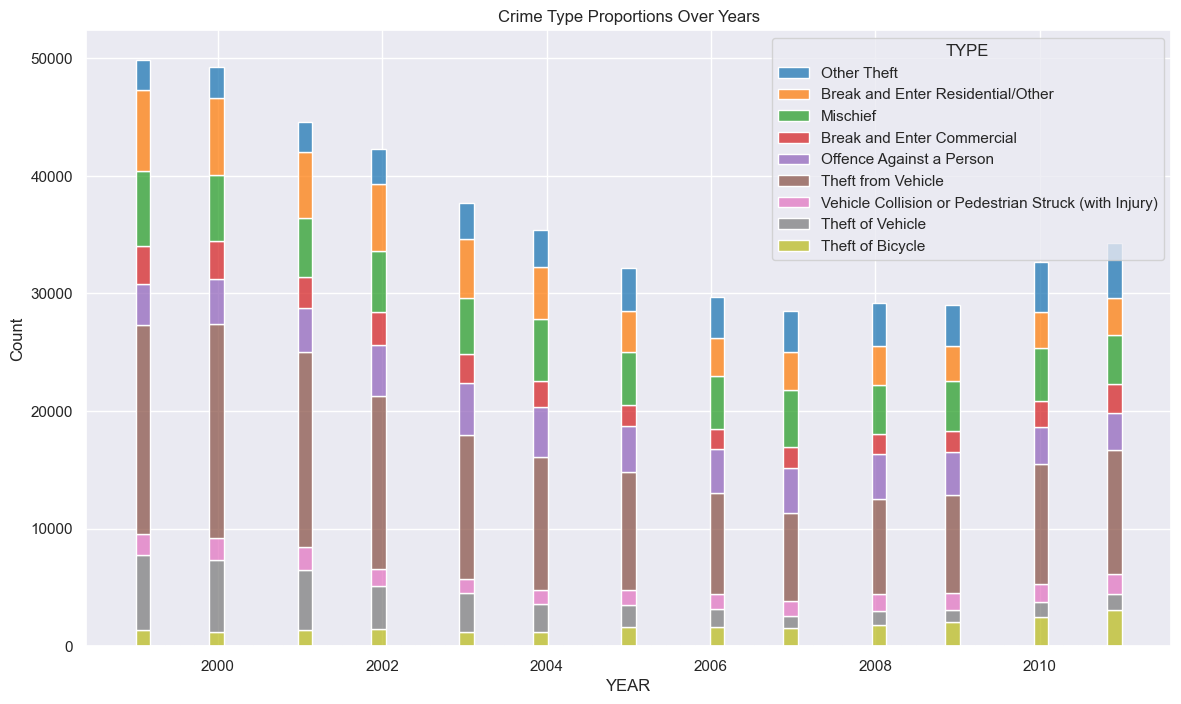

In [14]:
plt.figure(figsize=(14,8))
sns.histplot(data=df_clean, x='YEAR', hue='TYPE', multiple='stack', palette='tab10')
plt.title('Crime Type Proportions Over Years')
plt.show()

##### 1. Why did you pick the specific chart?
A stacked histogram reveals changes in proportions as well as total volume simultaneously.


##### 2. What is/are the insight(s) found from the chart?
Certain types of crime might diminish while others grow, replacing the raw volume.


##### 3. Will the gained insights help creating a positive business impact?
Identifies emerging threats versus addressed threats.


#### Chart - 6: Month over Month by Top 3 Crimes (Multivariate)


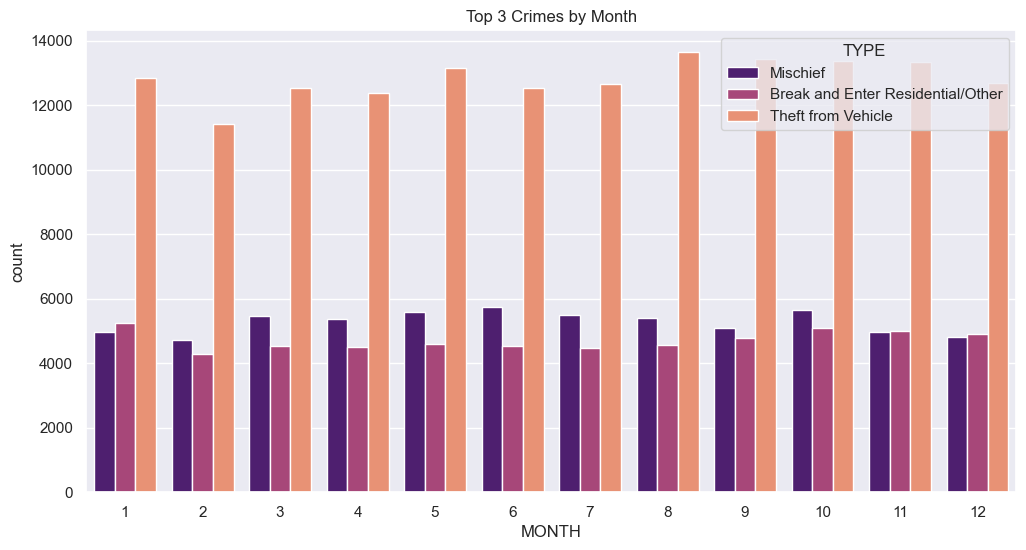

In [15]:
top_3_crimes = df_clean['TYPE'].value_counts().head(3).index
top_3_df = df_clean[df_clean['TYPE'].isin(top_3_crimes)]
plt.figure(figsize=(12,6))
sns.countplot(data=top_3_df, x='MONTH', hue='TYPE', palette='magma')
plt.title('Top 3 Crimes by Month')
plt.show()

##### Insights
The interactions between top crimes and specific months shows that property thefts spike differently than violent crimes.


#### Chart - 7: Incident Counts Distribution (Histogram)


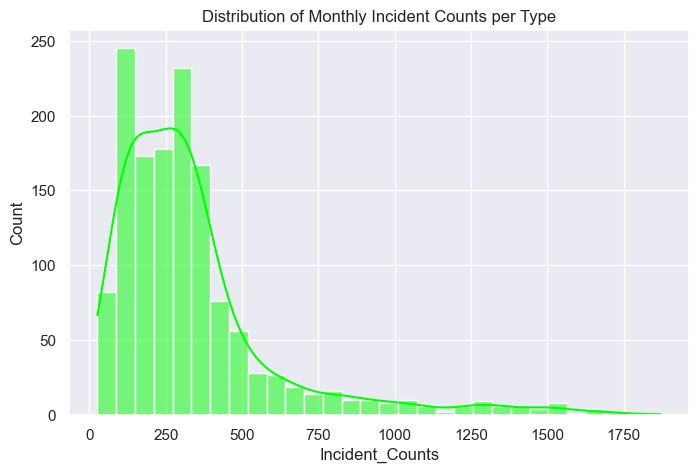

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_agg['Incident_Counts'], bins=30, kde=True, color='lime')
plt.title('Distribution of Monthly Incident Counts per Type')
plt.show()

##### Insights
The distribution is right-skewed; most Year/Month/Type groups have a smaller number of incidents, with a few extreme high-volume categories.


#### Chart - 8: Boxplot of Incident Counts by Crime Type


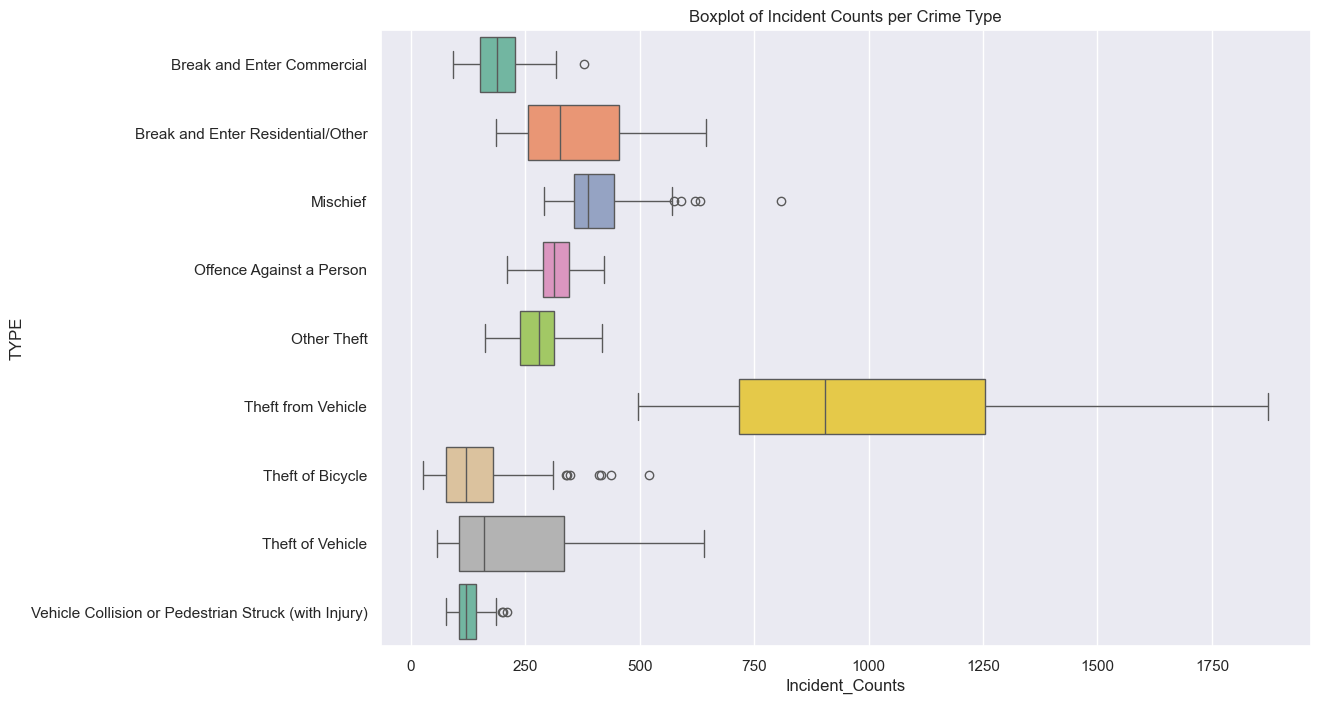

In [17]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_agg, x='Incident_Counts', y='TYPE', palette='Set2')
plt.title('Boxplot of Incident Counts per Crime Type')
plt.show()

##### Insights
Shows variance and outliers for each specific crime. Some crimes strictly happen in small numbers, while 'Theft from Vehicle' has massive outliers.


#### Chart - 9: Heatmap of Incidents by Month and Year


In [ ]:
pivot_df = df_agg.pivot_table(index='MONTH', columns='YEAR', values='Incident_Counts', aggfunc='sum')
plt.figure(figsize=(10,8))
sns.heatmap(pivot_df, cmap='inferno', annot=True, fmt='.0f')
plt.title('Heatmap of Total Incidents: Month vs Year')
plt.show()

##### Insights
The darkest/brightest zones immediately highlight the absolute worst months in recent history.


#### Chart - 10: Percentage Share of Crime Types (Pie)


In [ ]:
crime_shares = df_clean['TYPE'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(crime_shares, labels=crime_shares.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage Share of Crime Types')
plt.show()

##### Insights
Gives an immediate proportional breakdown.


#### Chart - 11: Mean Incidents per Month (Line)


In [ ]:
mean_month = df_agg.groupby('MONTH')['Incident_Counts'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=mean_month, x='MONTH', y='Incident_Counts', color='orange', linewidth=3)
plt.title('Average Incident Counts per Month')
plt.show()

##### Insights
Smoothes out the yearly variance to prove strict monthly seasonality.


#### Chart - 12: Scatter of Year vs Counts


In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_agg, x='YEAR', y='Incident_Counts', hue='TYPE', alpha=0.6)
plt.title('Scatter: Year vs Incident Counts by Type')
plt.show()

##### Insights
Highlights how different types cluster around different volume bands.


#### Chart - 13: Violin Plot of Counts by Year


In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df_agg, x='YEAR', y='Incident_Counts', palette='muted')
plt.title('Violin Plot showing Density of Counts by Year')
plt.show()

##### Insights
Shows the median and kde density of the Incident Counts grouped by year.


#### Chart - 14: Correlation Heatmap


In [ ]:
numeric_df = df_clean[['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE']].dropna()
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Temporal Features')
plt.show()

##### Insights
Checks if any temporal features are unusually correlated (e.g., certain days and months), mostly showing independence.


#### Chart - 15: Pairplot of Aggregated Dataset


In [ ]:
sns.pairplot(df_agg[['YEAR', 'MONTH', 'Incident_Counts']])
plt.suptitle('Pairplot of Aggregated Numerical Variables', y=1.02)
plt.show()

##### Insights
Provides a consolidated matrix of all numeric relationships.
